In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from src.utils import compute_individual_expectation_values, build_hva_layers, build_sparse_hamiltonian,find_best_initial_params,test_energy_consistency,optimize_energy

from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer, AerSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_ibm_runtime.fake_provider import FakeWashingtonV2, FakeAthensV2

from matplotlib import pyplot as plt
import sys
import numpy as np
from qiskit.quantum_info import Pauli, Statevector
from qiskit_aer.noise import NoiseModel, pauli_error
from qiskit.visualization import plot_gate_map
from qiskit.transpiler import CouplingMap

import pickle
import pandas as pd
import dill
with open("WS_TestFramework.dill", "rb") as f:
    globals().update(dill.load(f))



sys.path.append("../../pauli_lindblad_per/")
from tomography.experiment import SparsePauliTomographyExperiment as tomography

plt.style.use("ggplot")

In [ ]:
coupling = CouplingMap(couplinglist=[(0, 1), (1, 2), (1,0),(2,1)])
backend = GenericBackendV2(num_qubits=3, coupling_map=coupling)


hx = 1
hz = 1
J= -1
H_sparse = build_sparse_hamiltonian(hx, hz, backend, J=J)
best_guess, energy_exact = find_best_initial_params(H_sparse, backend)
opt_params, min_error = optimize_energy(best_guess, H_sparse, backend, energy_exact)
expectation_values, paulis = compute_individual_expectation_values(opt_params, backend, hx, hz,J=J, num_layers=1)
test_energy_consistency(opt_params, backend, hx, hz, J=-1)

Relativer Fehler      : 1.69e-16


In [6]:
params = [1,1,1]
expectation_values, paulis = compute_individual_expectation_values(params, backend, hx, hz,J=J, num_layers=1)
pauli_list = paulis
print(pauli_list)

['IIX', 'IIZ', 'IXI', 'IZI', 'XII', 'ZII', 'IZZ', 'ZZI']


In [7]:
df = pd.DataFrame({
    'Pauli': paulis,
    'Expectation Value': expectation_values
})
df

,Pauli,Expectation Value
0,IIX,0.021036
1,IIZ,0.708073
2,IXI,-0.326807
3,IZI,0.708073
4,XII,0.021036
5,ZII,0.708073
6,IZZ,0.501368
7,ZZI,0.501368


In [8]:
inst_map = [0,1,2]
qc = build_hva_layers(params, backend, qubit_indices=inst_map, num_layers=1)

qc.draw()

┌───┐┌───────┐┌───────┐                                      
q_0: ┤ H ├┤ Rz(1) ├┤ Rx(1) ├──■─────────────■─────────────────────
     ├───┤├───────┤├───────┤┌─┴─┐┌───────┐┌─┴─┐                   
q_1: ┤ H ├┤ Rz(1) ├┤ Rx(1) ├┤ X ├┤ Rz(1) ├┤ X ├──■─────────────■──
     ├───┤├───────┤├───────┤└───┘└───────┘└───┘┌─┴─┐┌───────┐┌─┴─┐
q_2: ┤ H ├┤ Rz(1) ├┤ Rx(1) ├───────────────────┤ X ├┤ Rz(1) ├┤ X ├
     └───┘└───────┘└───────┘                   └───┘└───────┘└───┘

In [9]:
for instr in qc.data:
    op = instr.operation
    qubits = instr.qubits
    q_indices = [qc.find_bit(q).index for q in qubits]
    print(f"{op.name} on qubits {q_indices}")

h on qubits [0]
h on qubits [1]
h on qubits [2]
rz on qubits [0]
rz on qubits [1]
rz on qubits [2]
rx on qubits [0]
rx on qubits [1]
rx on qubits [2]
cx on qubits [0, 1]
rz on qubits [1]
cx on qubits [0, 1]
cx on qubits [1, 2]
rz on qubits [2]
cx on qubits [1, 2]


In [10]:
# --- 1. Fehlerdefinitionen (anpassen nach Bedarf) ---

p1q = {
    0: {'X': 0.01, 'Y': 0.01, 'Z': 0.01},
    1: {'X': 0.015, 'Y': 0.005, 'Z': 0.01},
    2: {'X': 0.005, 'Y': 0.015, 'Z': 0.005},
}

p2q_cx = {
    (0, 1): {'IX': 0.01, 'XI': 0.01, 'ZZ': 0.015},
    (1, 2): {'XX': 0.015, 'YY': 0.005},
}

# --- 2. Hilfsfunktionen zum Erzeugen von Fehlern ---

def make_1q_pauli_error(pdict):
    pX = pdict.get('X', 0.0)
    pY = pdict.get('Y', 0.0)
    pZ = pdict.get('Z', 0.0)
    pI = 1.0 - (pX + pY + pZ)
    if pI < -1e-12:
        raise ValueError(f"Sum > 1: {pX + pY + pZ}")
    pI = max(pI, 0.0)
    terms = [(p, pdict[p]) for p in ['X', 'Y', 'Z'] if pdict.get(p, 0.0)]
    terms.append(('I', pI))
    return pauli_error(terms)

def make_2q_pauli_error(pdict):
    total = sum(pdict.values())
    pI = 1.0 - total
    if pI < -1e-12:
        raise ValueError(f"Sum > 1: {total}")
    pI = max(pI, 0.0)
    terms = [(label, p) for label, p in pdict.items()]
    terms.append(('II', pI))
    return pauli_error(terms)

# --- 3. Hole 1-Qubit-Gates aus BackendV2 (via Target API) ---

def get_1q_basis_gates(backend):
    oneq_gates = set()
    target = backend.target

    for inst, inst_props_list in target.instructions.items():
        for inst_props in inst_props_list:
            if len(inst_props.qubits) == 1:
                oneq_gates.add(inst.name)
    return sorted(oneq_gates)


# --- 4. NoiseModel erstellen ---
noise_model = NoiseModel()

#oneq_gates = get_1q_basis_gates(backend)

# 1Q-Fehler auf alle angegebenen Qubits anwenden
"""for q in p1q:
    error = make_1q_pauli_error(p1q[q])
    noise_model.add_quantum_error(error, oneq_gates, [q])"""

# 2Q-Fehler für bestimmte CNOT-Kanten
for (ctrl, tgt), paulis in p2q_cx.items():
    error = make_2q_pauli_error(paulis)
    noise_model.add_quantum_error(error, ['cx'], [ctrl, tgt])

# --- 5. Simulator instanziieren ---
simulator = AerSimulator(noise_model=noise_model)


In [ ]:
experiment = tomography(
    circuits = [qc], #list of circuits from which to get the layers requiring tomography
    inst_map = inst_map, #which physical qubits on the processor to map the qubits in the circuit
    backend = backend, #quantum backend
    used_qubits= inst_map
    )

experiment.generate(
    samples = 100, #Number of samples to take from the fidelity pair measurements
    single_samples = 250, #samples to take from the pair-breaking measurements
    depths = [2,4,16,32,64] #values of 2n to make the pair measurements. Numbers must be even and non-zero
    )

shots = 1024

#run the experiment
experiment.run(executor)
noisedataframe = experiment.analyze()

In [11]:
shots = 1024
def executor(circuits):
    return backend.run(circuits, shots = shots, noise_model=noise_model).result().get_counts()

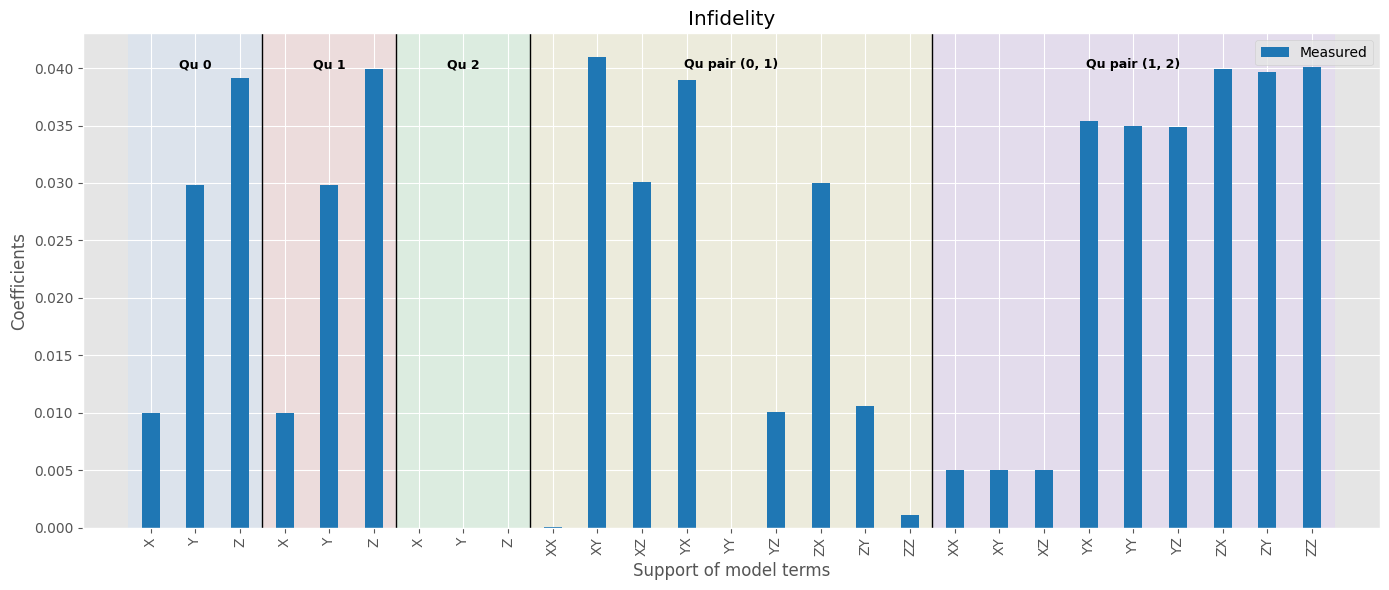

In [12]:
layer1 = experiment.analysis.get_layer_data(0)
layer1.plot_infidelitites(plot_style = 2)

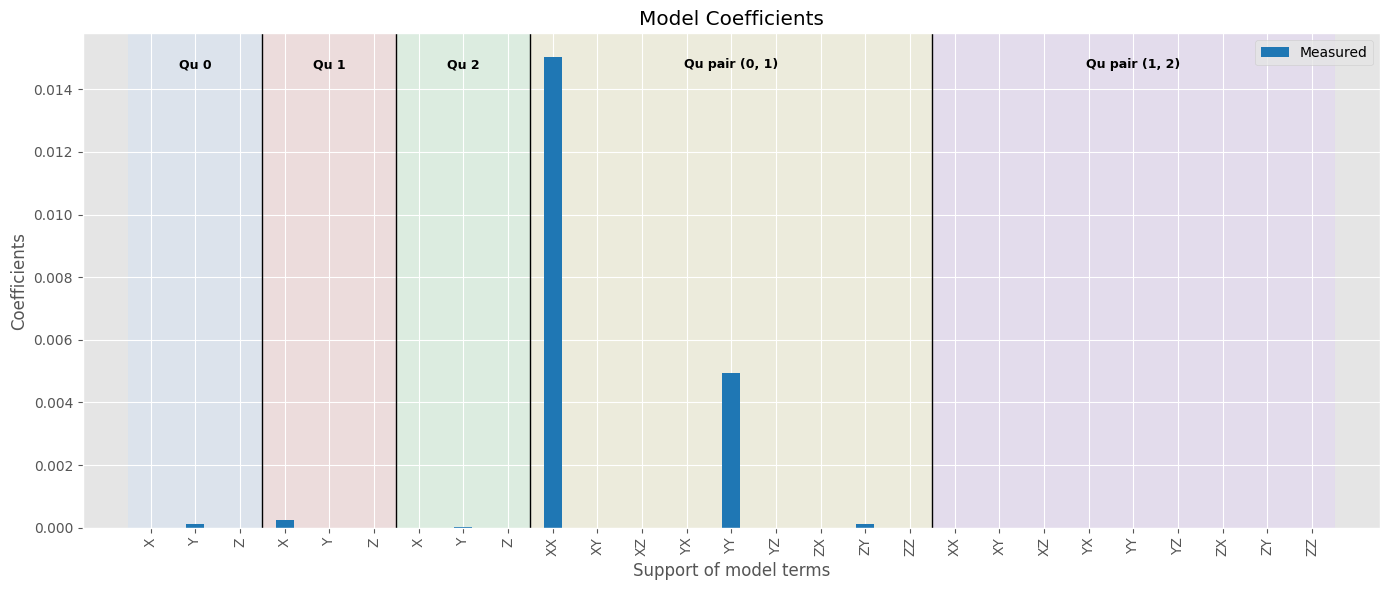

In [13]:
layer1.plot_coeffs(plot_style = 2)

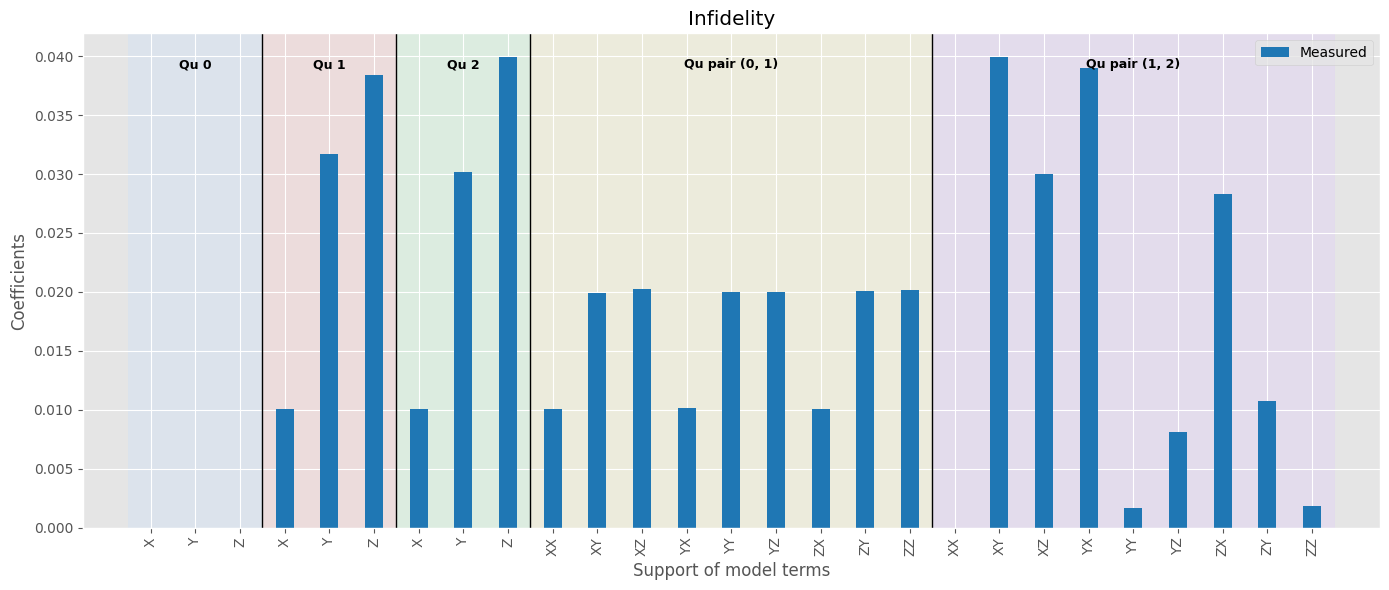

In [14]:
layer2 = experiment.analysis.get_layer_data(1)
layer2.plot_infidelitites(plot_style = 2)

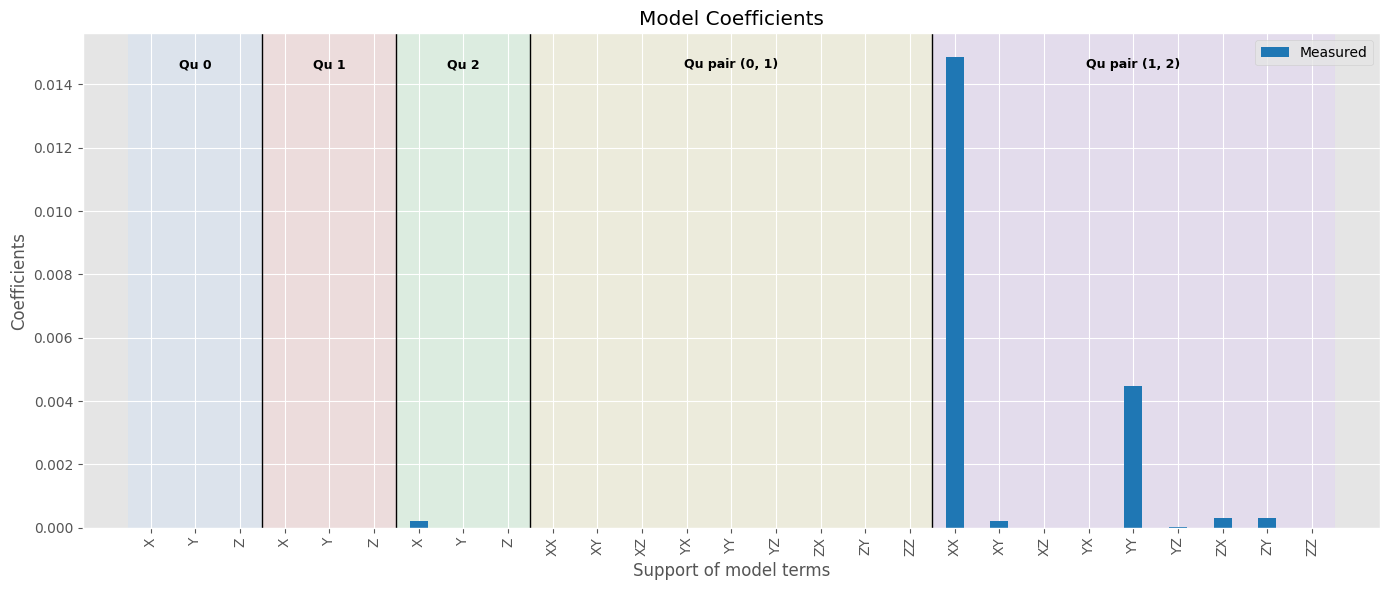

In [15]:
layer2.plot_coeffs(plot_style = 2)

In [16]:
# 2. PER-Experiment Setup
perexp = experiment.create_per_experiment([qc])

perexp.generate(
    expectations=pauli_list,
    samples=500,
    noise_strengths=[0, 1, 2]
)

# 3. Ausführen
perexp.run(executor)

Aus SV-Simulation:  0.7080734182735712


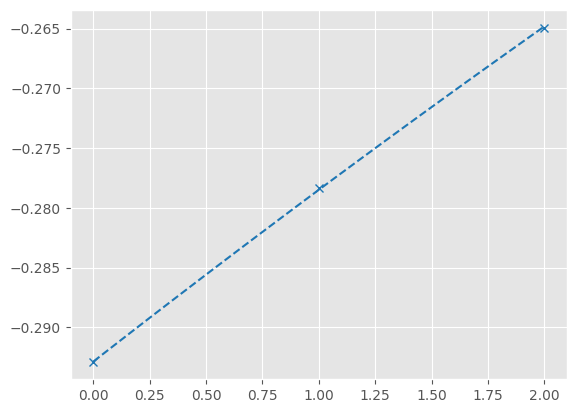

In [17]:
# 4. Analysieren
per_results = perexp.analyze()
result_1 = per_results[0].get_result(pauli_list[2]).plot()
print("Aus SV-Simulation: ",expectation_values[1])

In [22]:
# Compare absolute vs relative errors
for k in range(len(pauli_list)):
    exact = expectation_values[k]
    calc = per_results[0].get_result(pauli_list[k]).get_expectations()[0]
    abs_error = abs(exact - calc)
    rel_error = abs_error / abs(exact) if exact != 0 else float('inf')
    
    print(f"{pauli_list[k]}: Exact={exact:.4f}, Calc={calc:.4f}")
    print(f"  Absolute error: {abs_error:.6f}")
    print(f"  Relative error: {rel_error*100:.2f}%")
    print()

IIX: Exact=0.0210, Calc=0.0241
  Absolute error: 0.003091
  Relative error: 14.69%

IIZ: Exact=0.7081, Calc=0.7119
  Absolute error: 0.003833
  Relative error: 0.54%

IXI: Exact=-0.3268, Calc=-0.2929
  Absolute error: 0.033861
  Relative error: 10.36%

IZI: Exact=0.7081, Calc=0.7079
  Absolute error: 0.000203
  Relative error: 0.03%

XII: Exact=0.0210, Calc=0.0339
  Absolute error: 0.012908
  Relative error: 61.36%

ZII: Exact=0.7081, Calc=0.7169
  Absolute error: 0.008795
  Relative error: 1.24%

IZZ: Exact=0.5014, Calc=0.4966
  Absolute error: 0.004812
  Relative error: 0.96%

ZZI: Exact=0.5014, Calc=0.4906
  Absolute error: 0.010766
  Relative error: 2.15%



In [20]:
# After calling perexp.generate(), check what was created
print("Number of PER runs:", len(perexp._per_runs))
print("Number of instances in first run:", len(perexp._per_runs[0].instances))

# Look at the first few instances
per_run = perexp._per_runs[0]  # First (and only) circuit
instances = per_run.instances

print(f"\nTotal instances generated: {len(instances)}")

# Show details of first few instances
for i, instance in enumerate(instances[:10]):  # Show first 10
    print(f"\nInstance {i}:")
    print(f"  Measurement basis: {instance.meas_basis}")
    print(f"  Noise strength: {instance.noise_strength}")
    print(f"  Circuit depth: {instance.get_circuit().depth()}")
    print(f"  Circuit gates: {instance.get_circuit().count_ops()}")

# If you want to see the actual circuits:
print(f"\nFirst few circuits:")
for i in range(min(3, len(instances))):
    print(f"\nCircuit {i}:")
    print(instances[i].get_circuit().draw())

Number of PER runs: 1
Number of instances in first run: 3000

Total instances generated: 3000

Instance 0:
  Measurement basis: XXX
  Noise strength: 0
  Circuit depth: 18
  Circuit gates: OrderedDict([('rz', 22), ('sx', 9), ('barrier', 5), ('cx', 4), ('x', 3), ('measure', 3)])

Instance 1:
  Measurement basis: XXX
  Noise strength: 0
  Circuit depth: 18
  Circuit gates: OrderedDict([('rz', 22), ('sx', 9), ('barrier', 5), ('x', 5), ('cx', 4), ('measure', 3)])

Instance 2:
  Measurement basis: XXX
  Noise strength: 0
  Circuit depth: 18
  Circuit gates: OrderedDict([('rz', 19), ('sx', 9), ('barrier', 5), ('cx', 4), ('x', 3), ('measure', 3)])

Instance 3:
  Measurement basis: XXX
  Noise strength: 0
  Circuit depth: 17
  Circuit gates: OrderedDict([('rz', 20), ('sx', 9), ('barrier', 5), ('cx', 4), ('measure', 3), ('x', 2)])

Instance 4:
  Measurement basis: XXX
  Noise strength: 0
  Circuit depth: 24
  Circuit gates: OrderedDict([('rz', 27), ('sx', 11), ('x', 9), ('barrier', 5), ('cx', 4

In [21]:
# Check what measurement bases were chosen
print("Measurement bases:")
for i, basis in enumerate(perexp.meas_bases):
    print(f"  Basis {i}: {basis}")

print(f"\nExpectations to measure: {perexp._per_runs[0]._expectations}")
print(f"Noise strengths: {perexp._per_runs[0]._noise_strengths}")
print(f"Samples per combination: {perexp._per_runs[0]._samples}")

Measurement bases:
  Basis 0: XXX
  Basis 1: ZZZ

Expectations to measure: [IIX, IIZ, IXI, IZI, XII, ZII, IZZ, ZZI]
Noise strengths: [0, 1, 2]
Samples per combination: 500


In [ ]:
import dill

to_save = {
    'experiment': experiment,
    'noisedataframe': noisedataframe,
    'expectation_values': expectation_values,
    'backend': backend,
    'simulator': simulator,
    'paulis': paulis
}

with open("WS_TestFramework.dill", "wb") as f:
    dill.dump(to_save, f)